In [5]:
# %% [markdown]
# # 📊 Day 1 - Exploratory Data Analysis (EDA)
# ## NF-UQ-NIDS-v2 - Network Intrusion Detection Dataset
# 
# ### Objectives:
# - Load and understand the dataset
# - Analyze missing values
# - Visualize feature distributions
# - Correlation analysis
# - Target distribution analysis
# - Outlier detection

In [7]:
# %% Cell 1 - Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys
import yaml
import json
from datetime import datetime

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print("=" * 60)
print("📊 NF-UQ-NIDS-v2 - EXPLORATORY DATA ANALYSIS")
print("=" * 60)
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("✅ Libraries imported successfully!")

📊 NF-UQ-NIDS-v2 - EXPLORATORY DATA ANALYSIS
📅 Analysis Date: 2026-02-18 10:53:51
✅ Libraries imported successfully!


In [8]:
# %% Cell 2 - Load Configuration
config_path = Path("../config/config.yaml")

if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("✅ Configuration loaded")
    print(f"   Sample size: {config['data'].get('sample_size', 'N/A'):,}")
    print(f"   Test size: {config['data'].get('test_size', 'N/A')}")
else:
    print("⚠️ Config not found, using defaults")
    config = {
        'data': {
            'sample_path': '../data/processed/sample.csv',
            'raw_path': '../data/raw/NF-UQ-NIDS-v2.csv'
        }
    }

✅ Configuration loaded
   Sample size: 100,000
   Test size: 0.2


In [9]:
# %% Cell 3 - Define Paths
class Paths:
    ROOT = Path.cwd().parent
    RAW_DATA = ROOT / "data" / "raw" / "NF-UQ-NIDS-v2.csv"
    SAMPLE_DATA = ROOT / "data" / "processed" / "sample.csv"
    TRAIN_DATA = ROOT / "data" / "processed" / "train.csv"
    TEST_DATA = ROOT / "data" / "processed" / "test.csv"
    REPORTS = ROOT / "reports"
    
    @classmethod
    def check_paths(cls):
        print("\n📁 Checking data paths:")
        print(f"   Raw data exists: {cls.RAW_DATA.exists()}")
        print(f"   Sample data exists: {cls.SAMPLE_DATA.exists()}")
        print(f"   Train data exists: {cls.TRAIN_DATA.exists()}")
        print(f"   Test data exists: {cls.TEST_DATA.exists()}")

# Create reports directory
Paths.REPORTS.mkdir(parents=True, exist_ok=True)
Paths.check_paths()


📁 Checking data paths:
   Raw data exists: True
   Sample data exists: True
   Train data exists: True
   Test data exists: True


In [10]:
# %% Cell 4 - Load Dataset
def load_data():
    """Load data from available source"""
    
    # Priority: Sample > Train > Raw (sampled)
    if Paths.SAMPLE_DATA.exists():
        print(f"📂 Loading sample data: {Paths.SAMPLE_DATA}")
        df = pd.read_csv(Paths.SAMPLE_DATA, low_memory=False)
        source = "sample"
    elif Paths.TRAIN_DATA.exists():
        print(f"📂 Loading train data: {Paths.TRAIN_DATA}")
        df = pd.read_csv(Paths.TRAIN_DATA, low_memory=False)
        source = "train"
    elif Paths.RAW_DATA.exists():
        print(f"📂 Loading raw data (first 500K rows): {Paths.RAW_DATA}")
        df = pd.read_csv(Paths.RAW_DATA, nrows=500000, low_memory=False)
        source = "raw_sample"
    else:
        raise FileNotFoundError("No data file found! Run data_pipeline.py first.")
    
    print(f"✅ Data loaded from: {source}")
    print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"💾 Memory: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    
    return df, source

# Load the data
df, data_source = load_data()

📂 Loading sample data: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/data/processed/sample.csv
✅ Data loaded from: sample
📊 Shape: 100,000 rows × 46 columns
💾 Memory: 55.14 MB


In [11]:
# %% Cell 5 - Dataset Overview
print("\n" + "=" * 60)
print("📋 DATASET OVERVIEW")
print("=" * 60)

print(f"\n🔢 Dataset Dimensions:")
print(f"   • Rows: {df.shape[0]:,}")
print(f"   • Columns: {df.shape[1]}")

print(f"\n📊 Column Data Types:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   • {dtype}: {count}")

print(f"\n📋 Column Names:")
for i, col in enumerate(df.columns):
    print(f"   {i+1:2}. {col}")


📋 DATASET OVERVIEW

🔢 Dataset Dimensions:
   • Rows: 100,000
   • Columns: 46

📊 Column Data Types:
   • int64: 38
   • object: 4
   • float64: 4

📋 Column Names:
    1. IPV4_SRC_ADDR
    2. L4_SRC_PORT
    3. IPV4_DST_ADDR
    4. L4_DST_PORT
    5. PROTOCOL
    6. L7_PROTO
    7. IN_BYTES
    8. IN_PKTS
    9. OUT_BYTES
   10. OUT_PKTS
   11. TCP_FLAGS
   12. CLIENT_TCP_FLAGS
   13. SERVER_TCP_FLAGS
   14. FLOW_DURATION_MILLISECONDS
   15. DURATION_IN
   16. DURATION_OUT
   17. MIN_TTL
   18. MAX_TTL
   19. LONGEST_FLOW_PKT
   20. SHORTEST_FLOW_PKT
   21. MIN_IP_PKT_LEN
   22. MAX_IP_PKT_LEN
   23. SRC_TO_DST_SECOND_BYTES
   24. DST_TO_SRC_SECOND_BYTES
   25. RETRANSMITTED_IN_BYTES
   26. RETRANSMITTED_IN_PKTS
   27. RETRANSMITTED_OUT_BYTES
   28. RETRANSMITTED_OUT_PKTS
   29. SRC_TO_DST_AVG_THROUGHPUT
   30. DST_TO_SRC_AVG_THROUGHPUT
   31. NUM_PKTS_UP_TO_128_BYTES
   32. NUM_PKTS_128_TO_256_BYTES
   33. NUM_PKTS_256_TO_512_BYTES
   34. NUM_PKTS_512_TO_1024_BYTES
   35. NUM_PKTS_102

In [13]:
# %% Cell 6 - First Look at Data
print("\n" + "=" * 60)
print("👀 FIRST LOOK AT DATA")
print("=" * 60)

print("\n📋 First 20 Rows:")
df.head()


👀 FIRST LOOK AT DATA

📋 First 20 Rows:


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack,Dataset
0,5.101.40.105,63713,172.31.66.110,3389,6,0.0,1364,8,1721,7,222,222,26,0,0,0,98,98,1189,40,40,1189,1364.0,1721.0,0,0,0,0,10912000,13768000,10,3,0,1,1,8192,64000,0,0,0,0,0,0.0,0,Benign,NF-CSE-CIC-IDS2018-v2
1,192.168.1.32,60807,192.168.1.190,25182,6,0.0,48,1,40,1,22,2,20,0,0,0,0,0,48,40,40,48,48.0,40.0,0,0,0,0,384000,320000,2,0,0,0,0,4096,0,0,0,0,0,0,0.0,1,scanning,NF-ToN-IoT-v2
2,192.168.1.32,43860,192.168.1.79,1069,6,0.0,44,1,40,1,22,2,20,4294951,0,0,0,0,44,40,40,44,44.0,40.0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0.0,1,scanning,NF-ToN-IoT-v2
3,59.166.0.7,62102,149.171.126.1,22292,6,0.0,4654,80,74896,80,27,27,27,0,0,0,31,32,1367,52,52,1367,4654.0,74896.0,555,6,37028,32,37232000,599168000,106,0,0,0,54,52128,14480,11008,43,0,0,0,0.0,0,Benign,NF-UNSW-NB15-v2
4,192.168.100.150,11740,192.168.100.3,80,17,188.0,112,4,0,0,0,0,0,4293832,1135,0,64,64,28,28,0,28,8428.0,0.0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0.0,1,DDoS,NF-BoT-IoT-v2


In [14]:
# %% Cell 7 - Data Types Summary
print("\n📋 Detailed Column Information:")
print("-" * 80)

col_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.count().values,
    'Null': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique': df.nunique().values,
    'Sample Value': [df[col].iloc[0] if len(df) > 0 else None for col in df.columns]
})

print(col_info.to_string(index=False))


📋 Detailed Column Information:
--------------------------------------------------------------------------------
                     Column   Dtype  Non-Null  Null  Null %  Unique          Sample Value
              IPV4_SRC_ADDR  object    100000     0     0.0    3256          5.101.40.105
                L4_SRC_PORT   int64    100000     0     0.0   46049                 63713
              IPV4_DST_ADDR  object    100000     0     0.0    2301         172.31.66.110
                L4_DST_PORT   int64    100000     0     0.0    7904                  3389
                   PROTOCOL   int64    100000     0     0.0      22                     6
                   L7_PROTO float64    100000     0     0.0     136                   0.0
                   IN_BYTES   int64    100000     0     0.0    3678                  1364
                    IN_PKTS   int64    100000     0     0.0     256                     8
                  OUT_BYTES   int64    100000     0     0.0    4252          

In [15]:
# %% Cell 8 - Identify Column Types
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("\n" + "=" * 60)
print("📊 COLUMN CLASSIFICATION")
print("=" * 60)

print(f"\n🔢 Numerical Columns ({len(numerical_cols)}):")
for i, col in enumerate(numerical_cols, 1):
    print(f"   {i:2}. {col}")

print(f"\n📝 Categorical Columns ({len(categorical_cols)}):")
for i, col in enumerate(categorical_cols, 1):
    unique_count = df[col].nunique()
    print(f"   {i:2}. {col} (unique: {unique_count})")


📊 COLUMN CLASSIFICATION

🔢 Numerical Columns (42):
    1. L4_SRC_PORT
    2. L4_DST_PORT
    3. PROTOCOL
    4. L7_PROTO
    5. IN_BYTES
    6. IN_PKTS
    7. OUT_BYTES
    8. OUT_PKTS
    9. TCP_FLAGS
   10. CLIENT_TCP_FLAGS
   11. SERVER_TCP_FLAGS
   12. FLOW_DURATION_MILLISECONDS
   13. DURATION_IN
   14. DURATION_OUT
   15. MIN_TTL
   16. MAX_TTL
   17. LONGEST_FLOW_PKT
   18. SHORTEST_FLOW_PKT
   19. MIN_IP_PKT_LEN
   20. MAX_IP_PKT_LEN
   21. SRC_TO_DST_SECOND_BYTES
   22. DST_TO_SRC_SECOND_BYTES
   23. RETRANSMITTED_IN_BYTES
   24. RETRANSMITTED_IN_PKTS
   25. RETRANSMITTED_OUT_BYTES
   26. RETRANSMITTED_OUT_PKTS
   27. SRC_TO_DST_AVG_THROUGHPUT
   28. DST_TO_SRC_AVG_THROUGHPUT
   29. NUM_PKTS_UP_TO_128_BYTES
   30. NUM_PKTS_128_TO_256_BYTES
   31. NUM_PKTS_256_TO_512_BYTES
   32. NUM_PKTS_512_TO_1024_BYTES
   33. NUM_PKTS_1024_TO_1514_BYTES
   34. TCP_WIN_MAX_IN
   35. TCP_WIN_MAX_OUT
   36. ICMP_TYPE
   37. ICMP_IPV4_TYPE
   38. DNS_QUERY_ID
   39. DNS_QUERY_TYPE
   40. DNS_T

In [16]:
# %% Cell 9 - Statistical Summary (Numerical)
print("\n" + "=" * 60)
print("📊 STATISTICAL SUMMARY - NUMERICAL COLUMNS")
print("=" * 60)

stats = df[numerical_cols].describe().round(2)
print(stats.to_string())

# Save stats
stats.to_csv(Paths.REPORTS / "numerical_statistics.csv")
print(f"\n💾 Saved: {Paths.REPORTS / 'numerical_statistics.csv'}")


📊 STATISTICAL SUMMARY - NUMERICAL COLUMNS
       L4_SRC_PORT  L4_DST_PORT   PROTOCOL   L7_PROTO    IN_BYTES    IN_PKTS    OUT_BYTES   OUT_PKTS  TCP_FLAGS  CLIENT_TCP_FLAGS  SERVER_TCP_FLAGS  FLOW_DURATION_MILLISECONDS  DURATION_IN  DURATION_OUT    MIN_TTL    MAX_TTL  LONGEST_FLOW_PKT  SHORTEST_FLOW_PKT  MIN_IP_PKT_LEN  MAX_IP_PKT_LEN  SRC_TO_DST_SECOND_BYTES  DST_TO_SRC_SECOND_BYTES  RETRANSMITTED_IN_BYTES  RETRANSMITTED_IN_PKTS  RETRANSMITTED_OUT_BYTES  RETRANSMITTED_OUT_PKTS  SRC_TO_DST_AVG_THROUGHPUT  DST_TO_SRC_AVG_THROUGHPUT  NUM_PKTS_UP_TO_128_BYTES  NUM_PKTS_128_TO_256_BYTES  NUM_PKTS_256_TO_512_BYTES  NUM_PKTS_512_TO_1024_BYTES  NUM_PKTS_1024_TO_1514_BYTES  TCP_WIN_MAX_IN  TCP_WIN_MAX_OUT  ICMP_TYPE  ICMP_IPV4_TYPE  DNS_QUERY_ID  DNS_QUERY_TYPE  DNS_TTL_ANSWER  FTP_COMMAND_RET_CODE      Label
count    100000.00    100000.00  100000.00  100000.00   100000.00  100000.00     100000.0  100000.00  100000.00         100000.00         100000.00                   100000.00    100000.0

In [17]:
# %% Cell 10 - Identify Target Column
print("\n" + "=" * 60)
print("🎯 TARGET VARIABLE IDENTIFICATION")
print("=" * 60)

# Common target column names in NIDS datasets
target_candidates = ['Attack', 'Label', 'attack', 'label', 'target', 'class', 'Class']
target_col = None

for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        break

if target_col is None:
    # Try to find categorical column with reasonable number of unique values
    for col in categorical_cols:
        if 2 <= df[col].nunique() <= 50:
            target_col = col
            break

if target_col:
    print(f"✅ Target Column Identified: '{target_col}'")
    print(f"   • Unique Classes: {df[target_col].nunique()}")
    print(f"\n📊 Class Distribution:")
    class_dist = df[target_col].value_counts()
    for cls, count in class_dist.items():
        pct = count / len(df) * 100
        print(f"   • {cls}: {count:,} ({pct:.2f}%)")
else:
    print("⚠️ Target column not found! Please specify manually.")
    target_col = categorical_cols[0] if categorical_cols else None


🎯 TARGET VARIABLE IDENTIFICATION
✅ Target Column Identified: 'Attack'
   • Unique Classes: 20

📊 Class Distribution:
   • Benign: 32,986 (32.99%)
   • DDoS: 28,742 (28.74%)
   • DoS: 23,542 (23.54%)
   • scanning: 4,955 (4.96%)
   • Reconnaissance: 3,444 (3.44%)
   • xss: 3,217 (3.22%)
   • password: 1,519 (1.52%)
   • injection: 930 (0.93%)
   • Bot: 197 (0.20%)
   • Brute Force: 190 (0.19%)
   • Infilteration: 161 (0.16%)
   • Exploits: 34 (0.03%)
   • Fuzzers: 25 (0.03%)
   • Backdoor: 23 (0.02%)
   • Generic: 19 (0.02%)
   • mitm: 8 (0.01%)
   • ransomware: 3 (0.00%)
   • Shellcode: 2 (0.00%)
   • Analysis: 2 (0.00%)
   • Theft: 1 (0.00%)


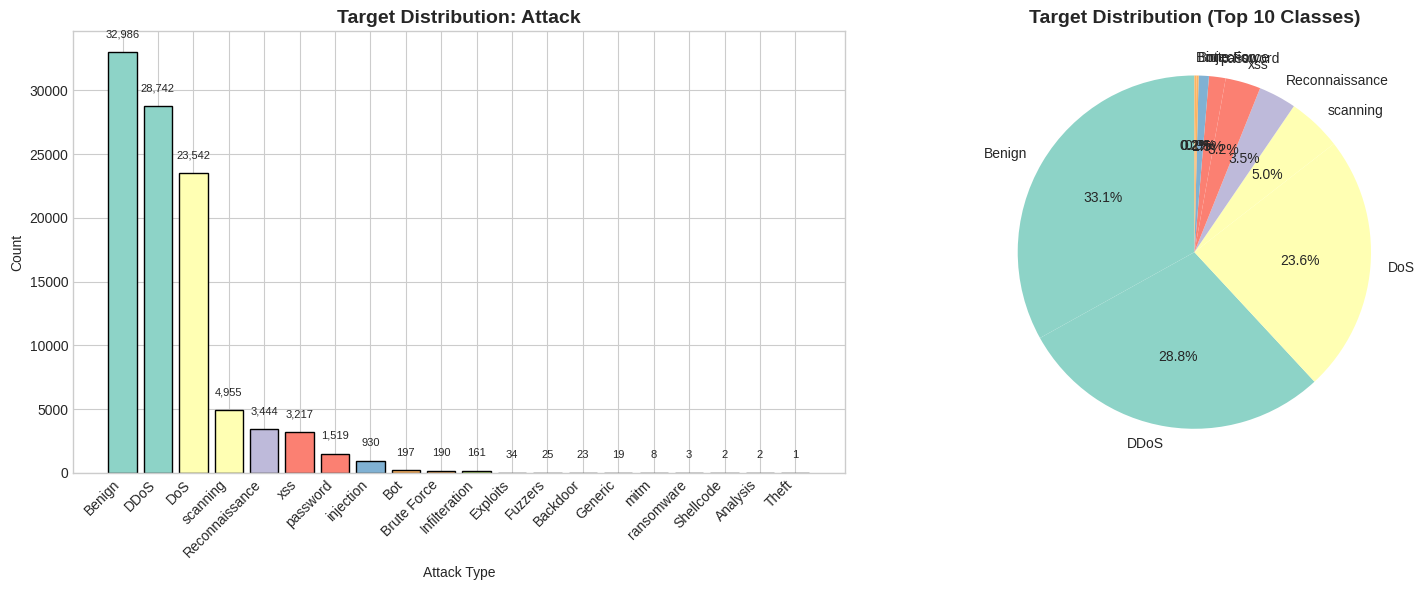

💾 Saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/target_distribution.png


In [18]:
# %% Cell 11 - Target Distribution Visualization
if target_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Get class distribution
    class_counts = df[target_col].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
    
    # Bar Plot
    ax1 = axes[0]
    bars = ax1.bar(range(len(class_counts)), class_counts.values, color=colors, edgecolor='black')
    ax1.set_xticks(range(len(class_counts)))
    ax1.set_xticklabels(class_counts.index, rotation=45, ha='right')
    ax1.set_xlabel('Attack Type')
    ax1.set_ylabel('Count')
    ax1.set_title(f'Target Distribution: {target_col}', fontsize=14, fontweight='bold')
    
    # Add value labels on bars
    for bar, val in zip(bars, class_counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01,
                f'{val:,}', ha='center', va='bottom', fontsize=8, rotation=0)
    
    # Pie Chart (Top 10 classes)
    ax2 = axes[1]
    top_classes = class_counts.head(10)
    ax2.pie(top_classes.values, labels=top_classes.index, autopct='%1.1f%%',
            colors=colors[:len(top_classes)], startangle=90)
    ax2.set_title(f'Target Distribution (Top 10 Classes)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(Paths.REPORTS / 'target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: {Paths.REPORTS / 'target_distribution.png'}")

In [19]:
# %% Cell 12 - Class Imbalance Analysis
if target_col:
    print("\n" + "=" * 60)
    print("⚖️ CLASS IMBALANCE ANALYSIS")
    print("=" * 60)
    
    class_counts = df[target_col].value_counts()
    
    # Calculate imbalance metrics
    max_class = class_counts.max()
    min_class = class_counts.min()
    imbalance_ratio = max_class / min_class
    
    print(f"\n📊 Imbalance Metrics:")
    print(f"   • Majority Class: {class_counts.idxmax()} ({max_class:,} samples)")
    print(f"   • Minority Class: {class_counts.idxmin()} ({min_class:,} samples)")
    print(f"   • Imbalance Ratio: {imbalance_ratio:.2f}:1")
    
    # Recommendations
    print(f"\n💡 Recommendations:")
    if imbalance_ratio > 100:
        print("   ⚠️ SEVERE imbalance! Consider:")
        print("      - SMOTE oversampling")
        print("      - Class weights in model")
        print("      - Undersampling majority class")
        print("      - Focal Loss for deep learning")
    elif imbalance_ratio > 10:
        print("   ⚠️ MODERATE imbalance. Consider:")
        print("      - Class weights")
        print("      - Stratified sampling")
    else:
        print("   ✅ Classes are relatively balanced")


⚖️ CLASS IMBALANCE ANALYSIS

📊 Imbalance Metrics:
   • Majority Class: Benign (32,986 samples)
   • Minority Class: Theft (1 samples)
   • Imbalance Ratio: 32986.00:1

💡 Recommendations:
   ⚠️ SEVERE imbalance! Consider:
      - SMOTE oversampling
      - Class weights in model
      - Undersampling majority class
      - Focal Loss for deep learning


In [20]:
# %% Cell 13 - Missing Values Analysis
print("\n" + "=" * 60)
print("🔍 MISSING VALUES ANALYSIS")
print("=" * 60)

# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)

# Show columns with missing values
missing_cols = missing_df[missing_df['Missing Count'] > 0]

if len(missing_cols) > 0:
    print(f"\n⚠️ Columns with Missing Values ({len(missing_cols)}):")
    print(missing_cols.to_string(index=False))
else:
    print("\n✅ No missing values in the dataset!")

# Total missing
total_cells = df.shape[0] * df.shape[1]
total_missing = missing.sum()
print(f"\n📊 Total Missing: {total_missing:,} / {total_cells:,} ({total_missing/total_cells*100:.4f}%)")


🔍 MISSING VALUES ANALYSIS

✅ No missing values in the dataset!

📊 Total Missing: 0 / 4,600,000 (0.0000%)


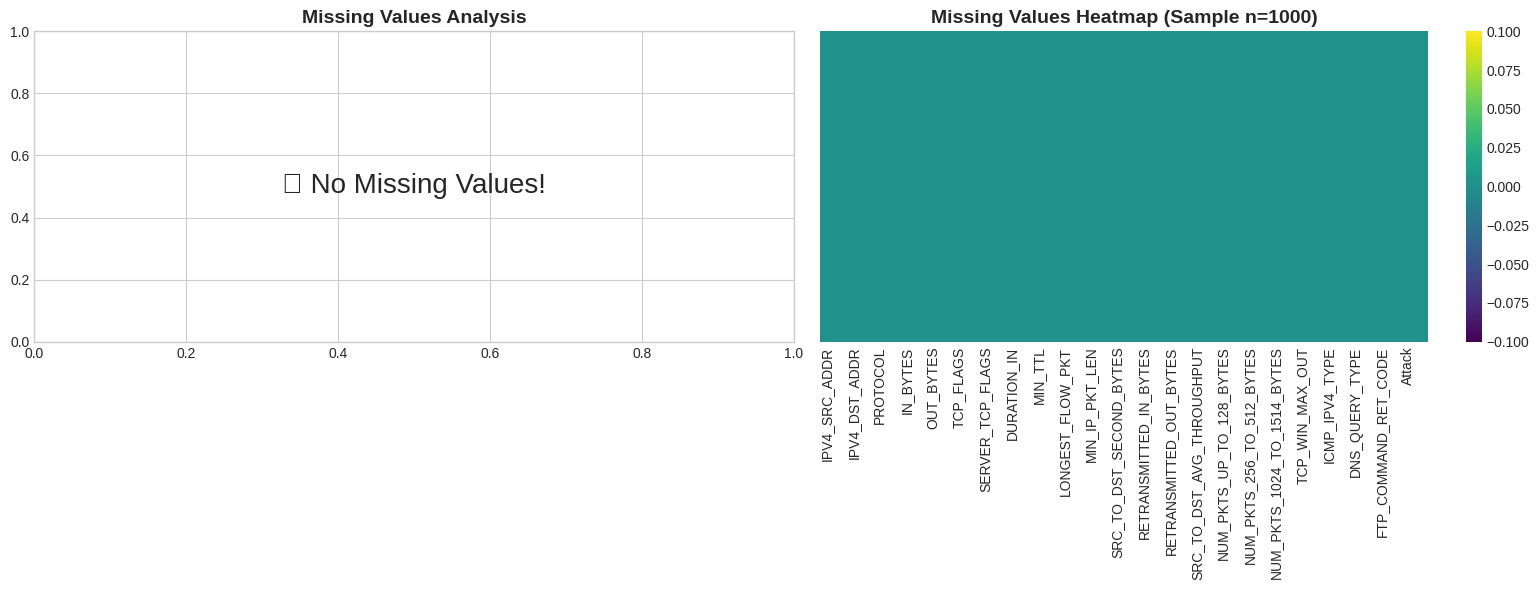

💾 Saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/missing_values.png


In [21]:
# %% Cell 14 - Missing Values Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of missing values
ax1 = axes[0]
missing_cols_plot = missing_df[missing_df['Missing Count'] > 0].head(20)
if len(missing_cols_plot) > 0:
    ax1.barh(missing_cols_plot['Column'], missing_cols_plot['Missing %'], color='coral')
    ax1.set_xlabel('Missing Percentage (%)')
    ax1.set_title('Top 20 Columns with Missing Values', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
else:
    ax1.text(0.5, 0.5, '✅ No Missing Values!', ha='center', va='center', 
             fontsize=20, transform=ax1.transAxes)
    ax1.set_title('Missing Values Analysis', fontsize=14, fontweight='bold')

# Heatmap of missing values (sample for performance)
ax2 = axes[1]
sample_size = min(1000, len(df))
sample_df = df.sample(sample_size, random_state=42)
sns.heatmap(sample_df.isnull(), cbar=True, yticklabels=False, ax=ax2, cmap='viridis')
ax2.set_title(f'Missing Values Heatmap (Sample n={sample_size})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(Paths.REPORTS / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {Paths.REPORTS / 'missing_values.png'}")


📊 FEATURE DISTRIBUTIONS


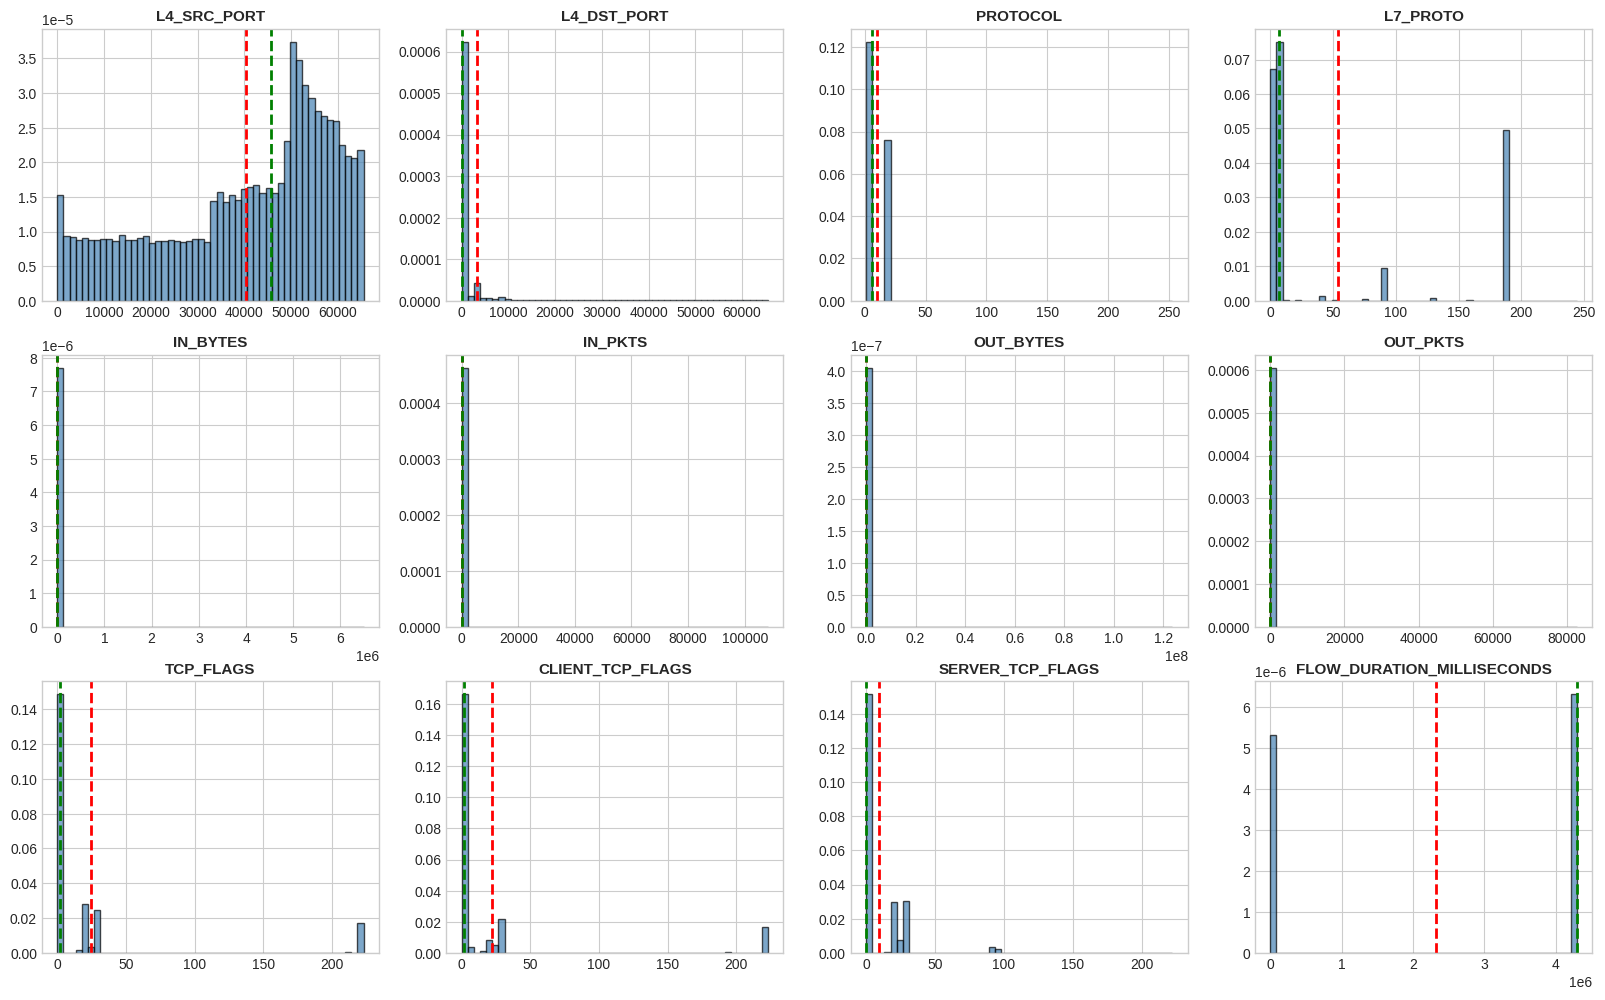

In [22]:
# %% Cell 15 - Feature Distributions
print("\n" + "=" * 60)
print("📊 FEATURE DISTRIBUTIONS")
print("=" * 60)

# Select features to visualize (first 12 numerical)
features_to_plot = numerical_cols[:12]
n_features = len(features_to_plot)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    ax = axes[i]
    
    # Clean data for plotting
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    
    # Plot histogram with KDE
    ax.hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)
    
    # Add statistics
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2e}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2e}')
    
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    

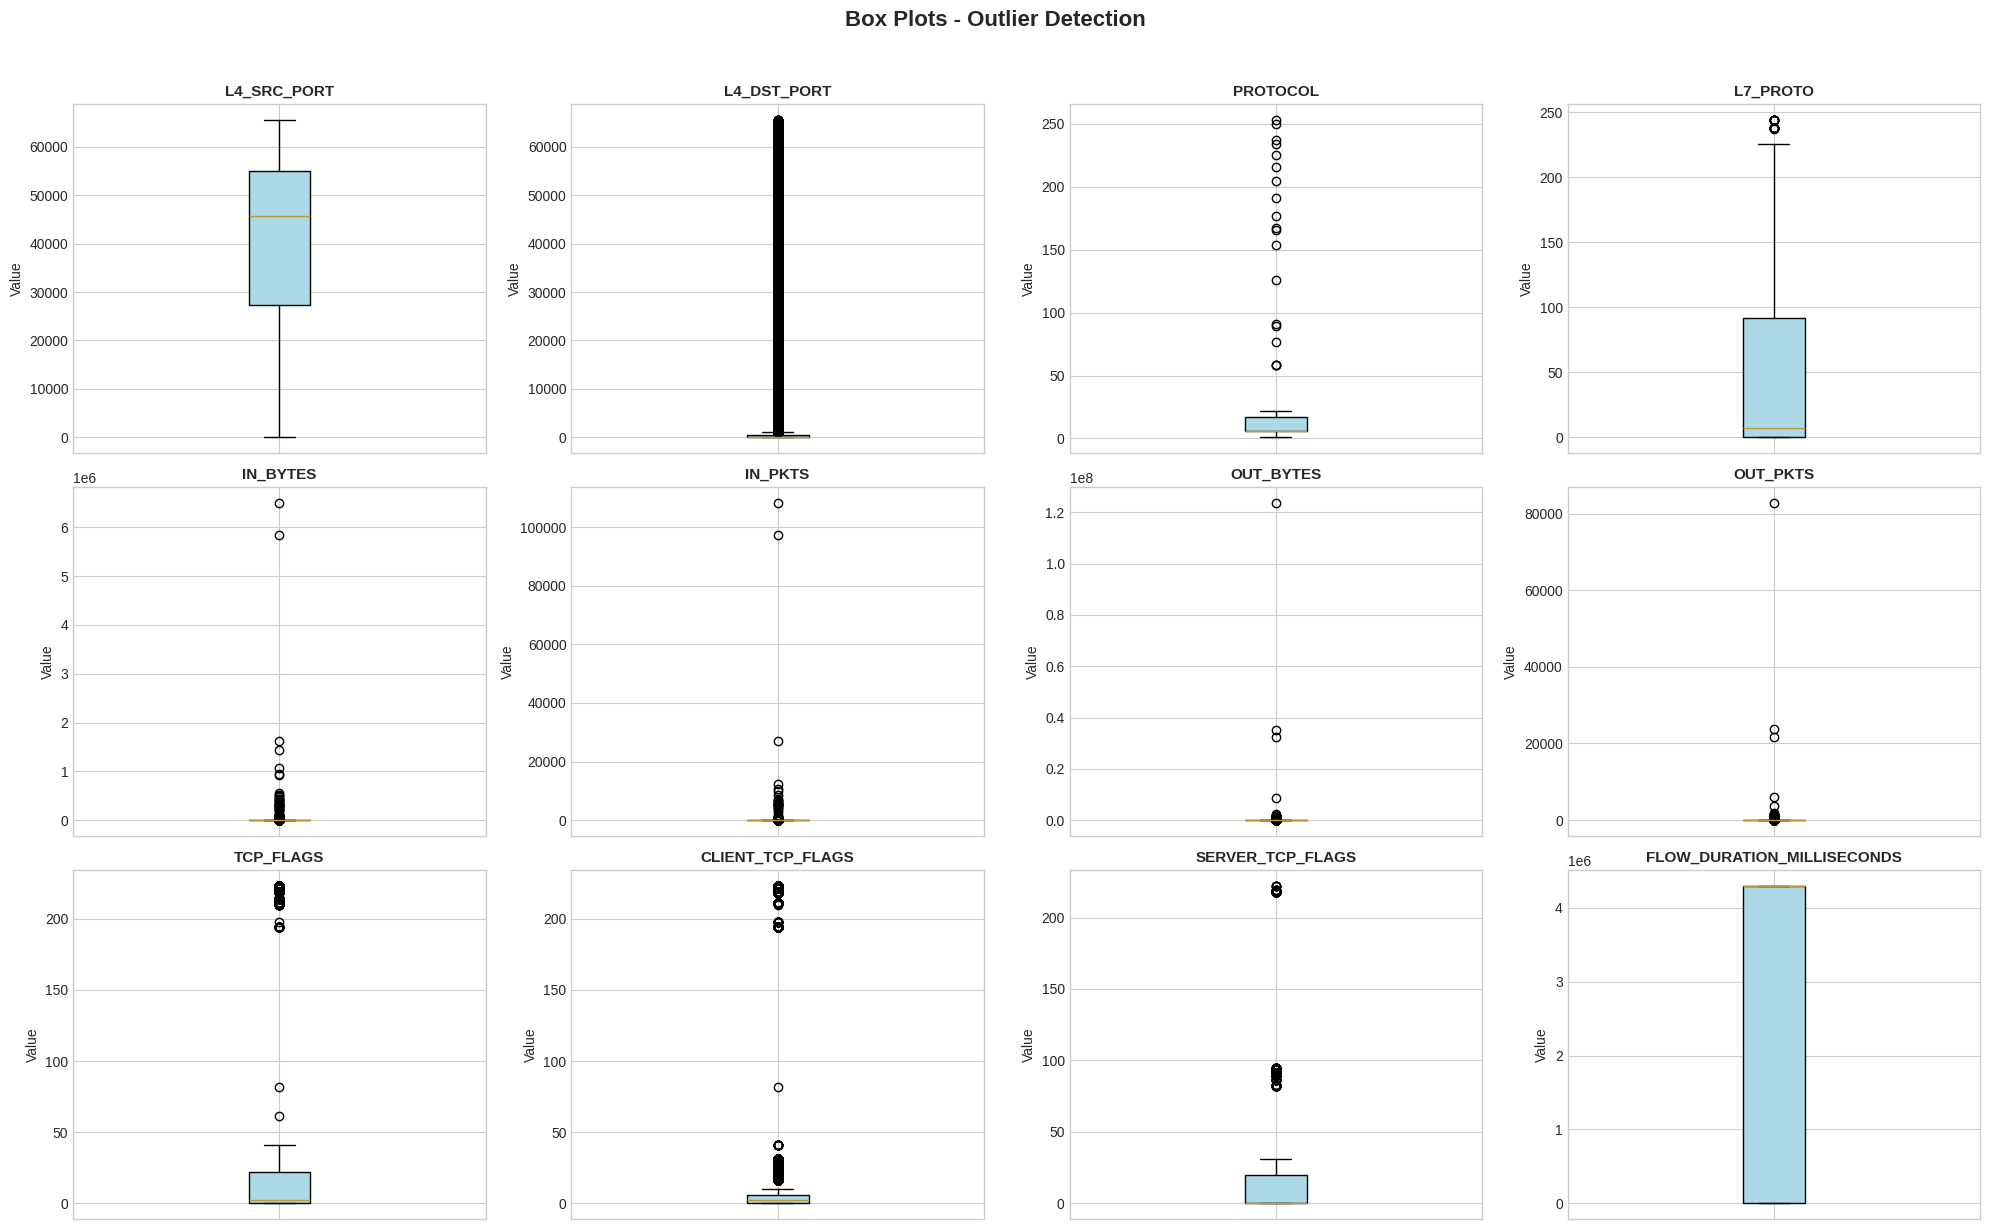

💾 Saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/boxplots_outliers.png


In [23]:
# %% Cell 16 - Box Plots for Outlier Visualization
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    ax = axes[i]
    
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    
    # Box plot
    bp = ax.boxplot(data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticklabels([''])

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Paths.REPORTS / 'boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {Paths.REPORTS / 'boxplots_outliers.png'}")

In [24]:
# %% Cell 17 - Outlier Detection Analysis
print("\n" + "=" * 60)
print("📊 OUTLIER DETECTION ANALYSIS")
print("=" * 60)

def detect_outliers_iqr(series):
    """Detect outliers using IQR method"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    return outliers, lower, upper

def detect_outliers_zscore(series, threshold=3):
    """Detect outliers using Z-score method"""
    mean = series.mean()
    std = series.std()
    if std == 0:
        return 0
    z_scores = np.abs((series - mean) / std)
    outliers = (z_scores > threshold).sum()
    return outliers

# Analyze outliers for each numerical column
outlier_results = []

for col in numerical_cols:
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(data) > 0:
        iqr_outliers, lower, upper = detect_outliers_iqr(data)
        zscore_outliers = detect_outliers_zscore(data)
        
        outlier_results.append({
            'Feature': col,
            'IQR Outliers': iqr_outliers,
            'IQR Outliers %': round(iqr_outliers / len(data) * 100, 2),
            'Z-Score Outliers': zscore_outliers,
            'Z-Score Outliers %': round(zscore_outliers / len(data) * 100, 2)
        })

outlier_df = pd.DataFrame(outlier_results).sort_values('IQR Outliers %', ascending=False)
print("\n📊 Outlier Summary (Top 15 by IQR %):")
print(outlier_df.head(15).to_string(index=False))

# Save outlier analysis
outlier_df.to_csv(Paths.REPORTS / 'outlier_analysis.csv', index=False)
print(f"\n💾 Saved: {Paths.REPORTS / 'outlier_analysis.csv'}")



📊 OUTLIER DETECTION ANALYSIS

📊 Outlier Summary (Top 15 by IQR %):
                  Feature  IQR Outliers  IQR Outliers %  Z-Score Outliers  Z-Score Outliers %
          TCP_WIN_MAX_OUT         24901           24.90              6343                6.34
         CLIENT_TCP_FLAGS         24203           24.20              7738                7.74
  SRC_TO_DST_SECOND_BYTES         22647           22.65                 0                0.00
                 OUT_PKTS         21796           21.80                29                0.03
        SHORTEST_FLOW_PKT         19724           19.72               125                0.12
              L4_DST_PORT         19568           19.57              3981                3.98
  DST_TO_SRC_SECOND_BYTES         18809           18.81                 0                0.00
                OUT_BYTES         18191           18.19                14                0.01
         LONGEST_FLOW_PKT         17351           17.35                 2             

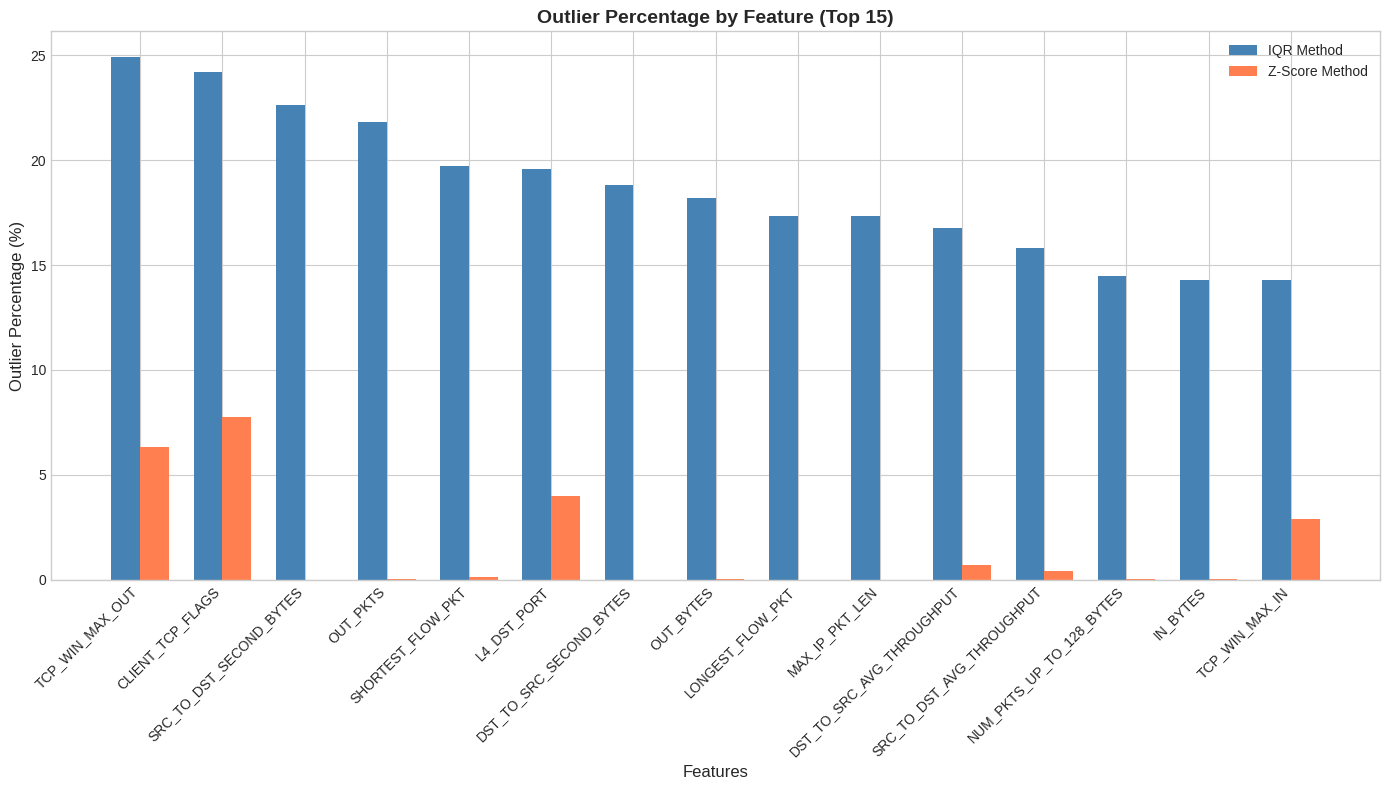

💾 Saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/outlier_percentage.png


In [25]:
# %% Cell 18 - Outlier Percentage Visualization
plt.figure(figsize=(14, 8))

top_outliers = outlier_df.head(15)
x = np.arange(len(top_outliers))
width = 0.35

plt.bar(x - width/2, top_outliers['IQR Outliers %'], width, label='IQR Method', color='steelblue')
plt.bar(x + width/2, top_outliers['Z-Score Outliers %'], width, label='Z-Score Method', color='coral')

plt.xlabel('Features', fontsize=12)
plt.ylabel('Outlier Percentage (%)', fontsize=12)
plt.title('Outlier Percentage by Feature (Top 15)', fontsize=14, fontweight='bold')
plt.xticks(x, top_outliers['Feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(Paths.REPORTS / 'outlier_percentage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {Paths.REPORTS / 'outlier_percentage.png'}")


📊 CORRELATION ANALYSIS


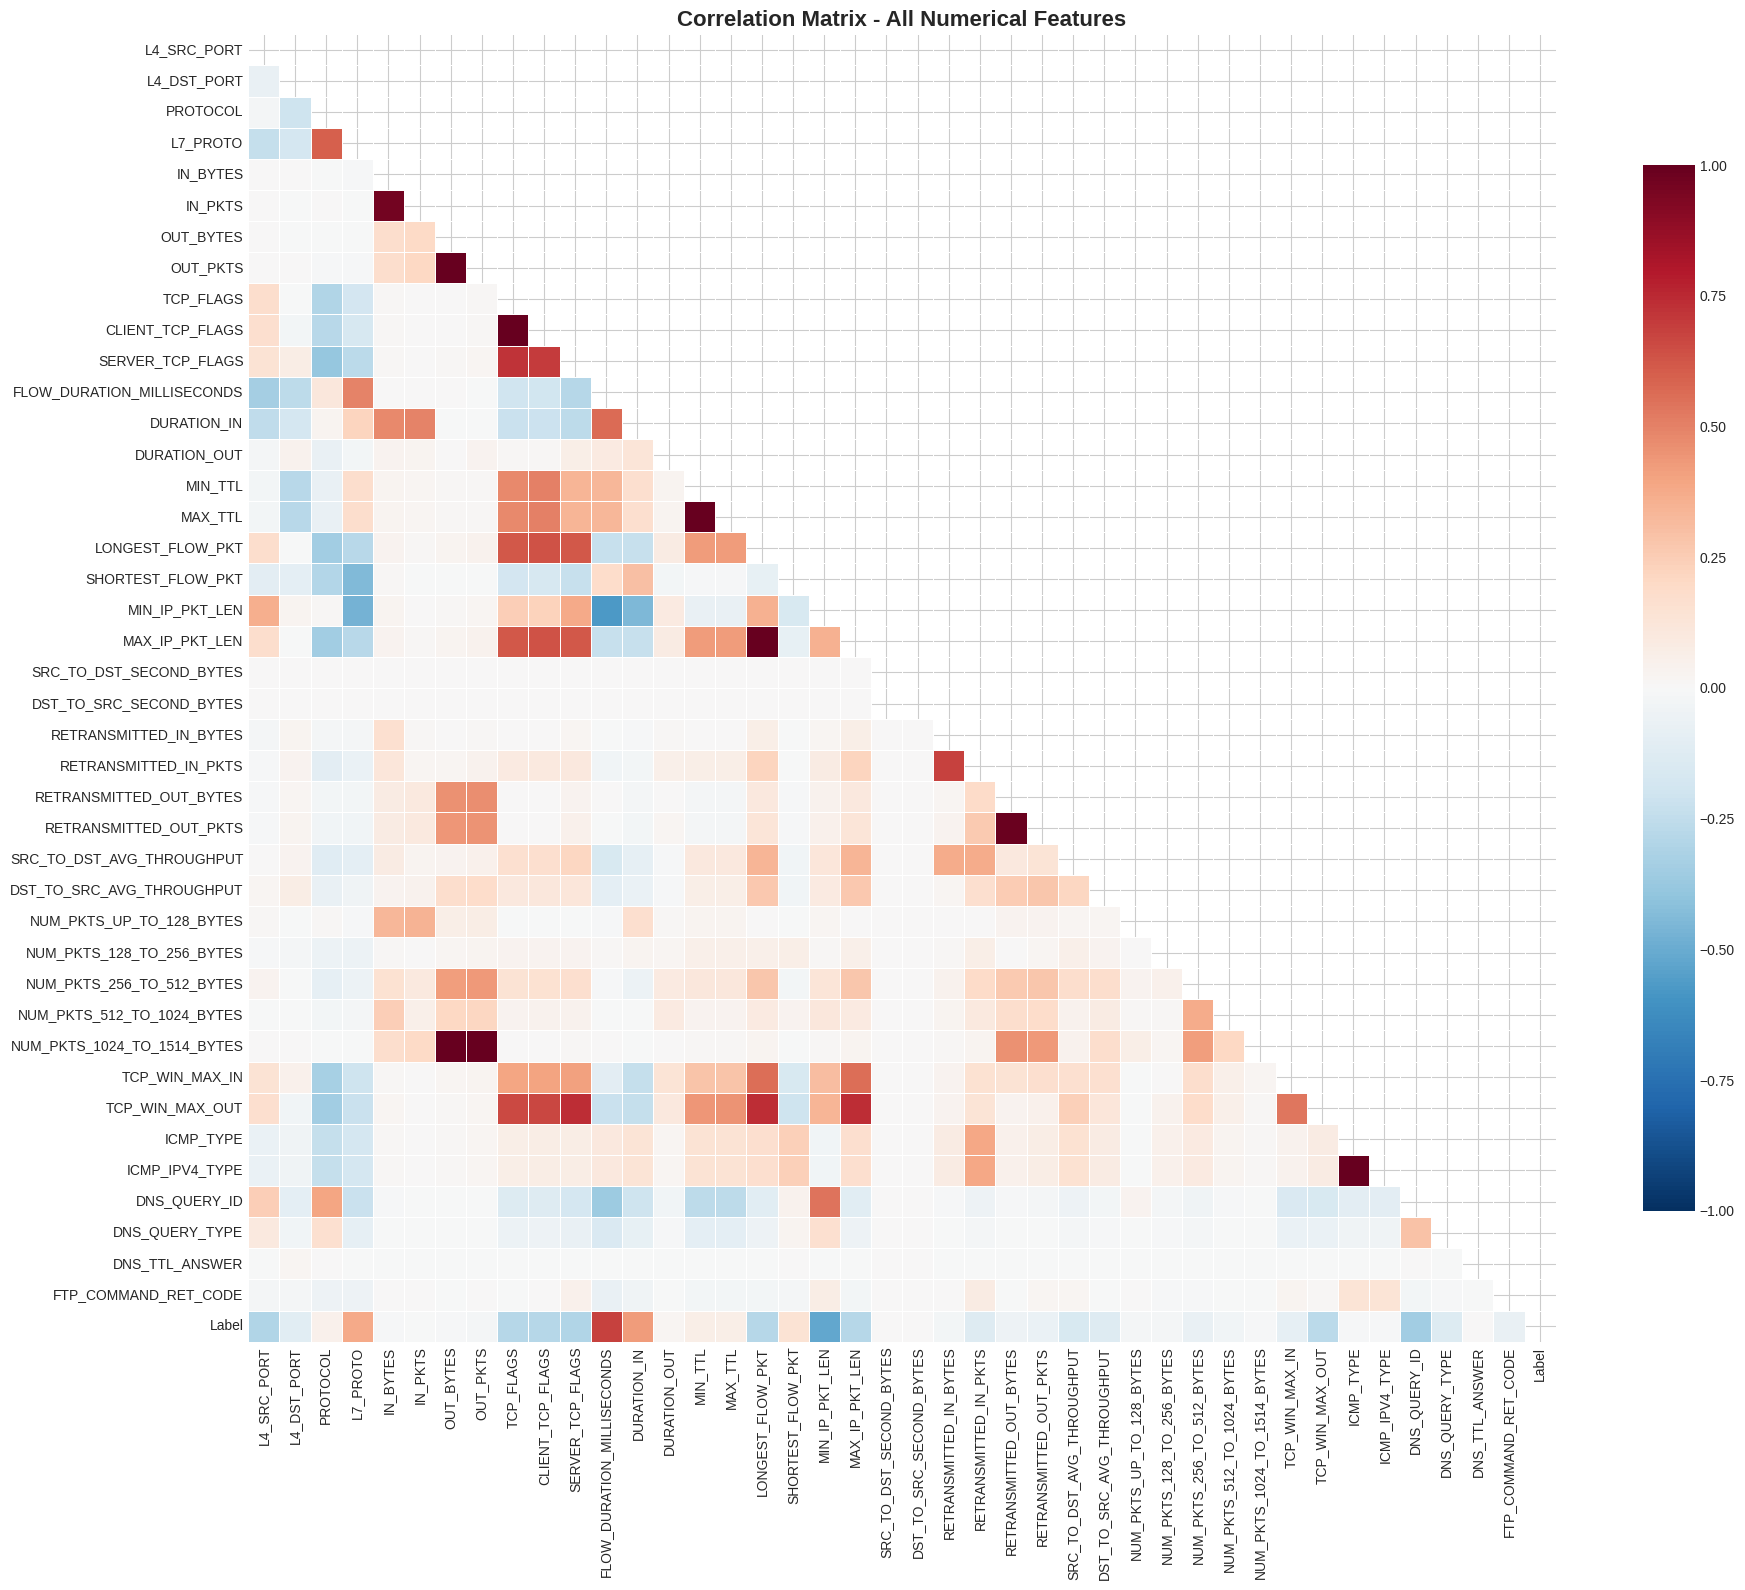

💾 Saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/correlation_matrix_full.png


In [26]:
# %% Cell 19 - Correlation Matrix
print("\n" + "=" * 60)
print("📊 CORRELATION ANALYSIS")
print("=" * 60)

# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()

# Full correlation heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix - All Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(Paths.REPORTS / 'correlation_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {Paths.REPORTS / 'correlation_matrix_full.png'}")

In [27]:
# %% Cell 20 - Highly Correlated Features
print("\n📊 Highly Correlated Feature Pairs (|r| > 0.8):")
print("-" * 60)

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_val, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)

if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
    print(f"\n📊 Total highly correlated pairs: {len(high_corr_df)}")
    
    # Save
    high_corr_df.to_csv(Paths.REPORTS / 'high_correlations.csv', index=False)
    print(f"💾 Saved: {Paths.REPORTS / 'high_correlations.csv'}")
else:
    print("✅ No highly correlated features found (|r| > 0.8)")
    


📊 Highly Correlated Feature Pairs (|r| > 0.8):
------------------------------------------------------------
              Feature 1                   Feature 2  Correlation
              OUT_BYTES NUM_PKTS_1024_TO_1514_BYTES        1.000
              ICMP_TYPE              ICMP_IPV4_TYPE        1.000
       LONGEST_FLOW_PKT              MAX_IP_PKT_LEN        1.000
                MIN_TTL                     MAX_TTL        0.999
              OUT_BYTES                    OUT_PKTS        0.999
               OUT_PKTS NUM_PKTS_1024_TO_1514_BYTES        0.999
              TCP_FLAGS            CLIENT_TCP_FLAGS        0.995
RETRANSMITTED_OUT_BYTES      RETRANSMITTED_OUT_PKTS        0.991
               IN_BYTES                     IN_PKTS        0.965

📊 Total highly correlated pairs: 9
💾 Saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/high_correlations.csv


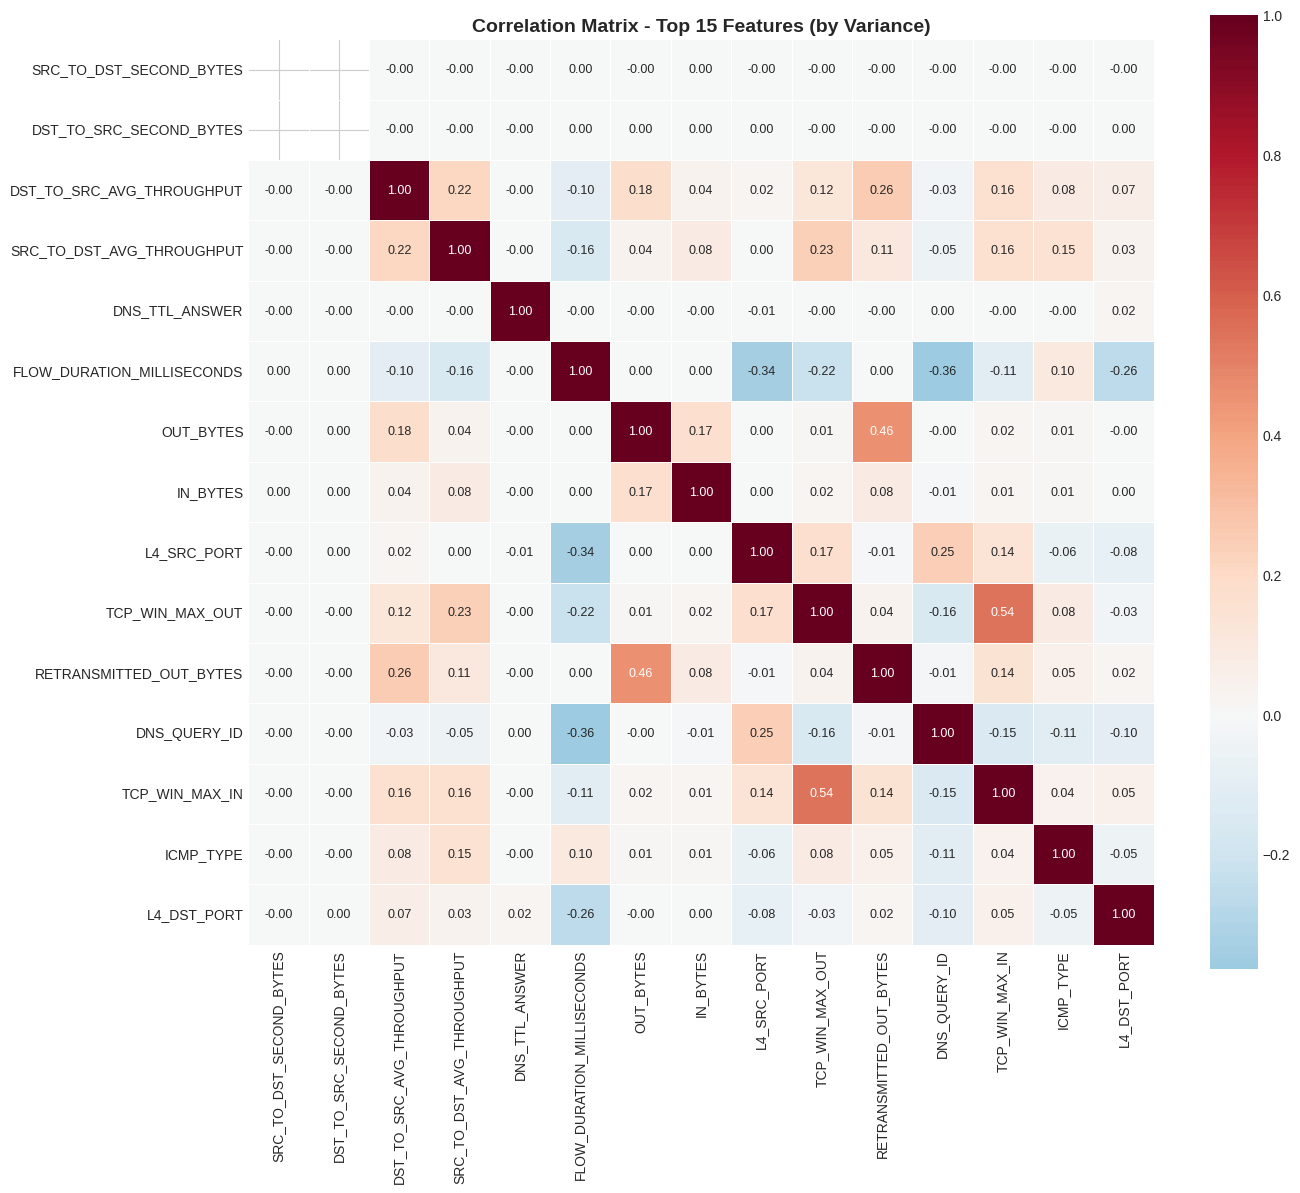

💾 Saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/correlation_matrix_top15.png


In [28]:
# %% Cell 21 - Top Features Correlation Heatmap
# Select top 15 features by variance
top_var_features = df[numerical_cols].var().nlargest(15).index.tolist()

plt.figure(figsize=(14, 12))
corr_subset = df[top_var_features].corr()
sns.heatmap(
    corr_subset,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix - Top 15 Features (by Variance)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Paths.REPORTS / 'correlation_matrix_top15.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {Paths.REPORTS / 'correlation_matrix_top15.png'}")


📊 FEATURE DISTRIBUTION BY TARGET CLASS


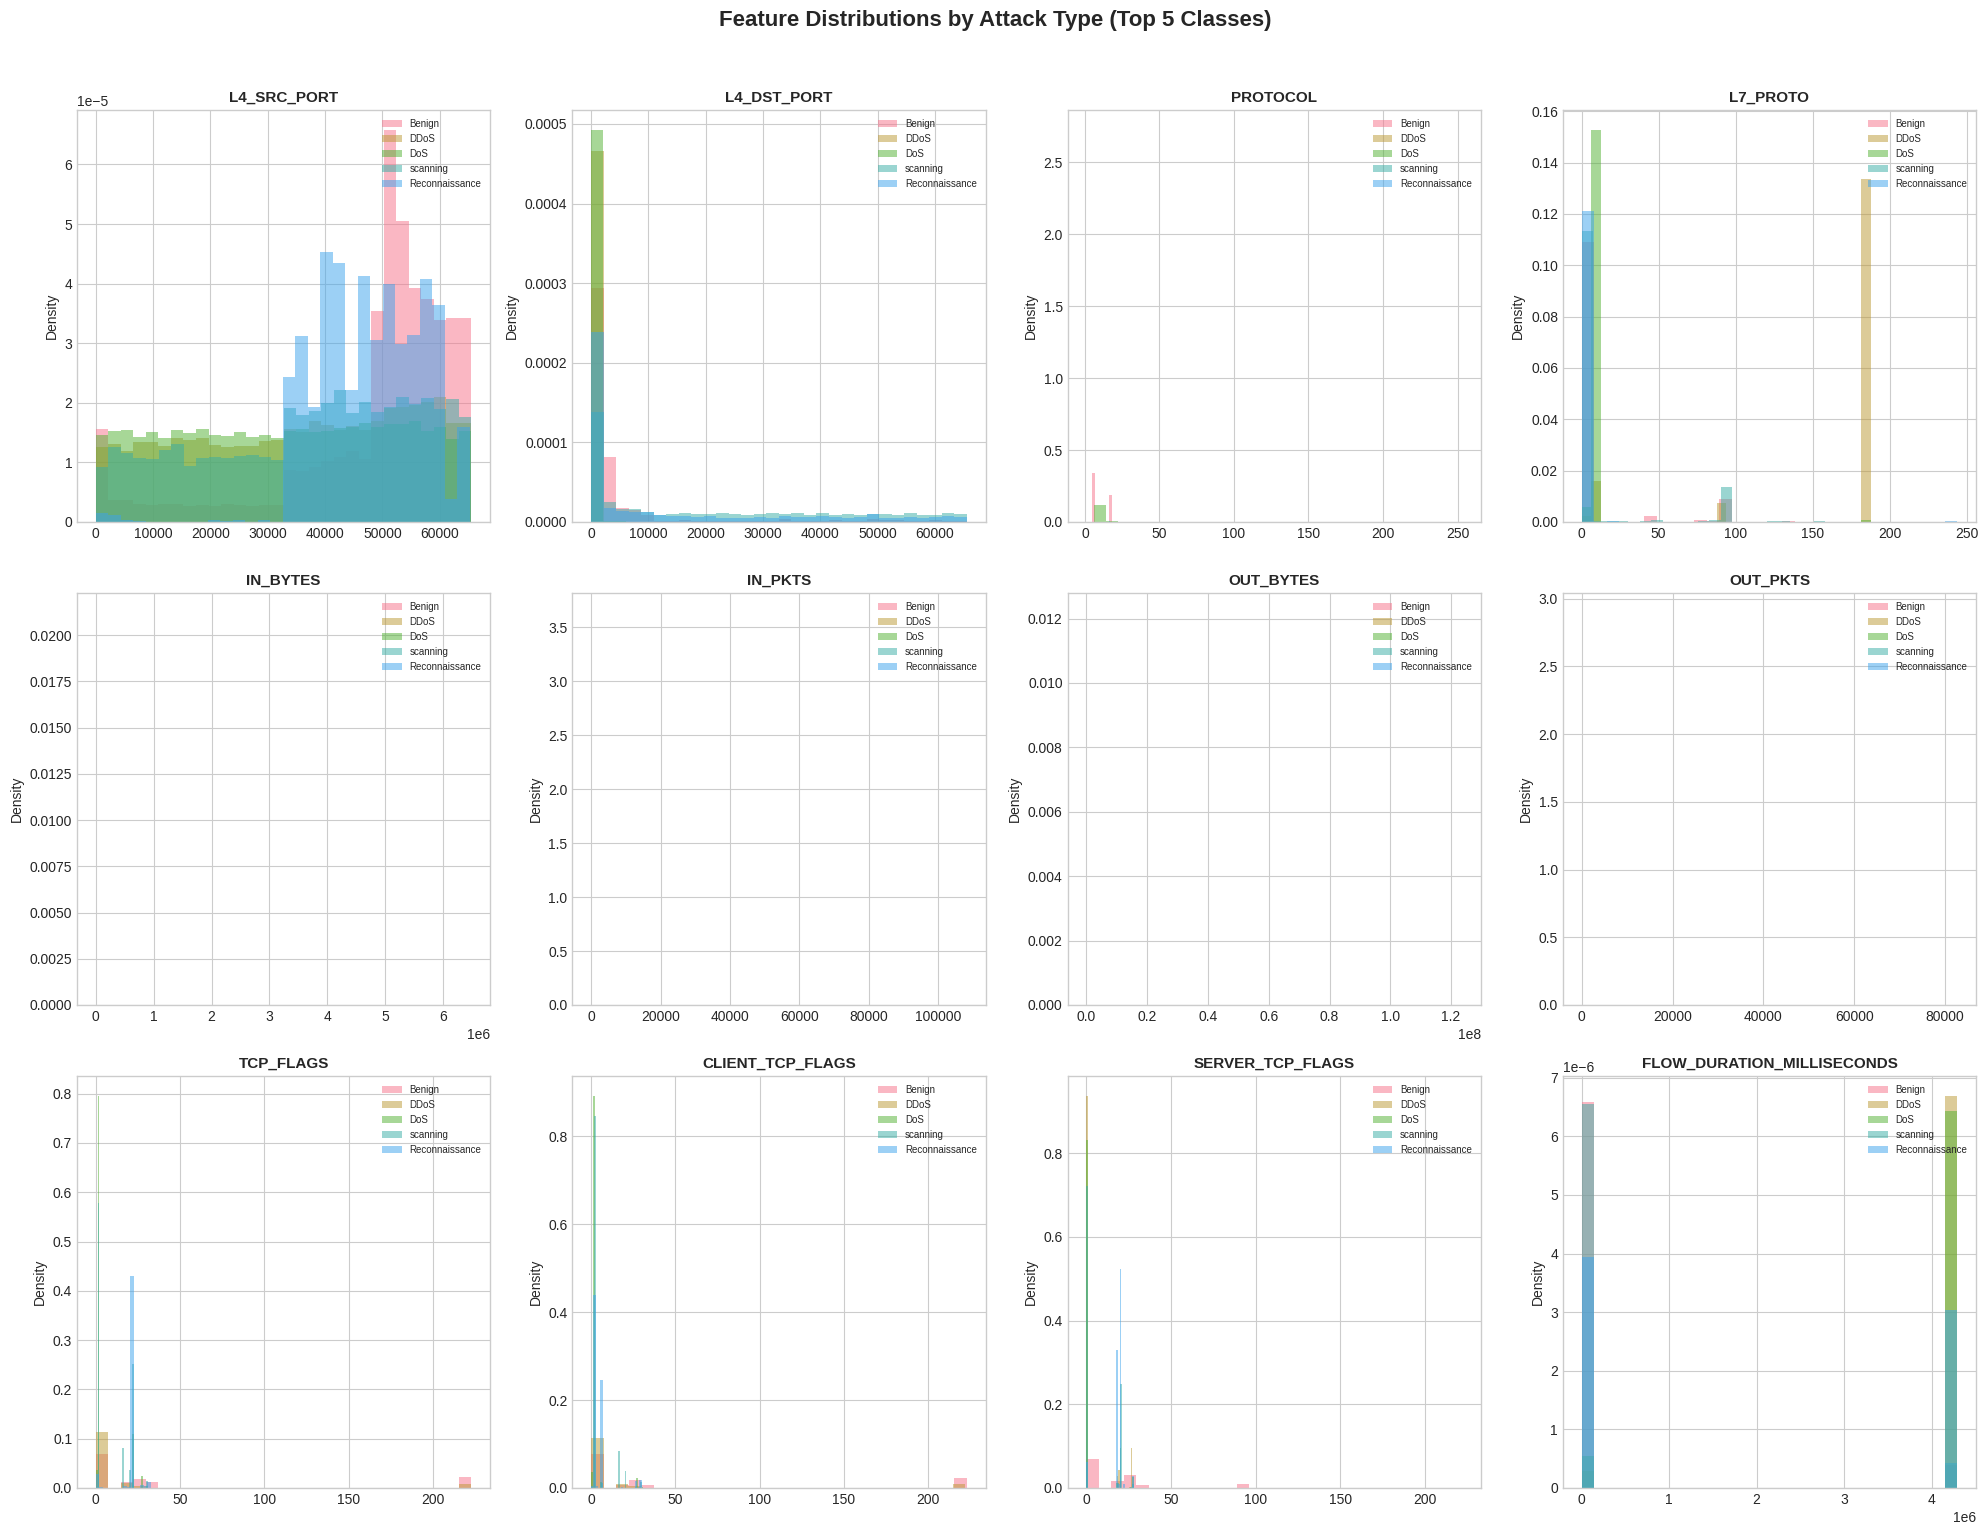

💾 Saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/feature_by_target.png


In [29]:
# %% Cell 22 - Feature Distribution by Target Class
if target_col and target_col in df.columns:
    print("\n" + "=" * 60)
    print("📊 FEATURE DISTRIBUTION BY TARGET CLASS")
    print("=" * 60)
    
    # Get top 5 classes for visualization
    top_classes = df[target_col].value_counts().head(5).index.tolist()
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(features_to_plot):
        if i >= 12:
            break
        ax = axes[i]
        
        for cls in top_classes:
            data = df[df[target_col] == cls][col].replace([np.inf, -np.inf], np.nan).dropna()
            if len(data) > 0:
                ax.hist(data, bins=30, alpha=0.5, label=str(cls)[:15], density=True)
        
        ax.set_title(f'{col}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=7, loc='upper right')
        ax.set_xlabel('')
        ax.set_ylabel('Density')
    
    plt.suptitle('Feature Distributions by Attack Type (Top 5 Classes)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(Paths.REPORTS / 'feature_by_target.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: {Paths.REPORTS / 'feature_by_target.png'}")

In [30]:
# %% Cell 23 - Duplicate Analysis
print("\n" + "=" * 60)
print("📊 DUPLICATE ANALYSIS")
print("=" * 60)

# Check for duplicates
n_duplicates = df.duplicated().sum()
duplicate_pct = n_duplicates / len(df) * 100

print(f"\n📋 Duplicate Rows:")
print(f"   • Total Duplicates: {n_duplicates:,}")
print(f"   • Percentage: {duplicate_pct:.2f}%")

if n_duplicates > 0:
    print(f"\n⚠️ Recommendation: Consider removing {n_duplicates:,} duplicate rows")
else:
    print("\n✅ No duplicate rows found!")


📊 DUPLICATE ANALYSIS

📋 Duplicate Rows:
   • Total Duplicates: 0
   • Percentage: 0.00%

✅ No duplicate rows found!


In [31]:
# %% Cell 24 - Data Quality Summary
print("\n" + "=" * 60)
print("📋 DATA QUALITY SUMMARY")
print("=" * 60)

quality_metrics = {
    'Total Rows': f"{len(df):,}",
    'Total Columns': f"{len(df.columns)}",
    'Numerical Columns': f"{len(numerical_cols)}",
    'Categorical Columns': f"{len(categorical_cols)}",
    'Total Missing Values': f"{df.isnull().sum().sum():,}",
    'Missing Percentage': f"{df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100:.4f}%",
    'Duplicate Rows': f"{df.duplicated().sum():,}",
    'Duplicate Percentage': f"{df.duplicated().sum() / len(df) * 100:.2f}%",
    'Memory Usage': f"{df.memory_usage(deep=True).sum() / (1024**2):.2f} MB",
    'Target Column': target_col if target_col else 'Not identified',
    'Number of Classes': f"{df[target_col].nunique()}" if target_col else 'N/A',
    'Class Imbalance Ratio': f"{imbalance_ratio:.2f}:1" if target_col else 'N/A'
}

print("\n📊 Quality Metrics:")
for key, value in quality_metrics.items():
    print(f"   • {key}: {value}")


📋 DATA QUALITY SUMMARY

📊 Quality Metrics:
   • Total Rows: 100,000
   • Total Columns: 46
   • Numerical Columns: 42
   • Categorical Columns: 4
   • Total Missing Values: 0
   • Missing Percentage: 0.0000%
   • Duplicate Rows: 0
   • Duplicate Percentage: 0.00%
   • Memory Usage: 55.14 MB
   • Target Column: Attack
   • Number of Classes: 20
   • Class Imbalance Ratio: 32986.00:1


In [33]:
# %% Cell 25 - Generate EDA Report
print("\n" + "=" * 60)
print("📝 GENERATING EDA REPORT")
print("=" * 60)

# Get values safely
total_rows = len(df)
total_cols = len(df.columns)
num_cols_count = len(numerical_cols)
cat_cols_count = len(categorical_cols)
memory_mb = df.memory_usage(deep=True).sum() / (1024**2)
missing_total = df.isnull().sum().sum()
missing_pct = missing_total / (total_rows * total_cols) * 100
duplicate_count = df.duplicated().sum()
duplicate_pct = duplicate_count / total_rows * 100

# Target info
if target_col and target_col in df.columns:
    target_info = target_col
    n_classes = df[target_col].nunique()
    class_dist = df[target_col].value_counts().to_string()
    imbalance_str = f"{imbalance_ratio:.2f}:1"
else:
    target_info = "Not identified"
    n_classes = "N/A"
    class_dist = "N/A"
    imbalance_str = "N/A"

# High correlation info
if len(high_corr_df) > 0:
    high_corr_str = high_corr_df.head(20).to_string()
else:
    high_corr_str = "No highly correlated features found"

# Outlier info
outlier_str = outlier_df.head(10).to_string()

# Generate report
report_content = f"""# EDA Report - NF-UQ-NIDS-v2 Dataset
## Network Intrusion Detection System Analysis

**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Data Source:** {data_source}

---

## Dataset Overview

| Metric | Value |
|--------|-------|
| Total Rows | {total_rows:,} |
| Total Columns | {total_cols} |
| Numerical Columns | {num_cols_count} |
| Categorical Columns | {cat_cols_count} |
| Memory Usage | {memory_mb:.2f} MB |

---

## Target Variable

- **Target Column:** {target_info}
- **Number of Classes:** {n_classes}
- **Imbalance Ratio:** {imbalance_str}

### Class Distribution:
{class_dist}

---

## Data Quality

| Metric | Value |
|--------|-------|
| Missing Values | {missing_total:,} |
| Missing Percentage | {missing_pct:.4f}% |
| Duplicate Rows | {duplicate_count:,} |
| Duplicate Percentage | {duplicate_pct:.2f}% |

---

## Highly Correlated Features

{high_corr_str}

Total pairs: {len(high_corr_df)}

---

## Outlier Summary (Top 10)

{outlier_str}

---

## Recommendations

1. Class Imbalance: Handle using SMOTE or class weights if ratio > 10
2. Missing Values: {'No action needed' if missing_total == 0 else 'Apply imputation'}
3. Duplicates: {'No action needed' if duplicate_count == 0 else 'Remove duplicates'}
4. High Correlations: {'Consider feature selection' if len(high_corr_df) > 10 else 'Acceptable'}

---

## Generated Visualizations

- target_distribution.png
- missing_values.png
- feature_distributions.png
- boxplots_outliers.png
- correlation_matrix_full.png
- correlation_matrix_top15.png
- feature_by_target.png
- outlier_percentage.png

---

## Day 1 EDA Complete!
"""

# Save report
report_path = Paths.REPORTS / 'DATA-REPORT.md'
with open(report_path, 'w') as f:
    f.write(report_content)

print(f"✅ EDA Report saved: {report_path}")


📝 GENERATING EDA REPORT
✅ EDA Report saved: /home/prateek/Documents/HESTABIT_TASKS_3rd_BATCH/WEEK_6-MACHINE_LEARNING_ENGINEERING/DAY_1-DATA_PIPELINE_EDA/src/reports/DATA-REPORT.md


In [34]:
# %% Cell 26 - Final Summary
print("\n" + "=" * 60)
print("✅ DAY 1 EDA COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("""
📁 Generated Files:
""")

# List all generated files
for file in Paths.REPORTS.glob('*'):
    print(f"   ✅ {file.name}")

print(f"""
📊 Key Findings:
   • Dataset: {len(df):,} rows × {len(df.columns)} columns
   • Target: {target_col} ({df[target_col].nunique() if target_col else 'N/A'} classes)
   • Missing Values: {df.isnull().sum().sum():,}
   • Duplicates: {df.duplicated().sum():,}
   • High Correlation Pairs: {len(high_corr_df)}

🎯 Next Steps (Day 2):
   • Feature Engineering
   • Feature Selection
   • Data Transformation
   • Model Training Preparation

✅ Day 1 Complete! Ready for Day 2!
""")


✅ DAY 1 EDA COMPLETED SUCCESSFULLY!

📁 Generated Files:

   ✅ feature_by_target.png
   ✅ high_correlations.csv
   ✅ outlier_percentage.png
   ✅ correlation_matrix_full.png
   ✅ correlation_matrix_top15.png
   ✅ outlier_analysis.csv
   ✅ DATA-REPORT.md
   ✅ missing_values.png
   ✅ numerical_statistics.csv
   ✅ target_distribution.png
   ✅ boxplots_outliers.png

📊 Key Findings:
   • Dataset: 100,000 rows × 46 columns
   • Target: Attack (20 classes)
   • Missing Values: 0
   • Duplicates: 0
   • High Correlation Pairs: 9

🎯 Next Steps (Day 2):
   • Feature Engineering
   • Feature Selection
   • Data Transformation
   • Model Training Preparation

✅ Day 1 Complete! Ready for Day 2!

